# YOLOv8 с Ultralytics
This notebook:
- Object detection with a pre-trained model
- Results analysis (bounding boxes, classes, confidence)
- Manually drawing bounding boxes
- Training on a custom mask dataset

In [2]:

!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00


In [3]:

import os
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 4. Training on a custom mask dataset

[Glasses Detector](https://www.kaggle.com/datasets/mantasu/glasses-detector).

We will use only one class `detection/worn`



In [4]:
dataset_path = '/content/glasses_dataset'
!kaggle datasets download mantasu/glasses-detector --unzip -p {dataset_path}


Dataset URL: https://www.kaggle.com/datasets/mantasu/glasses-detector
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 2.23G/2.23G [00:20<00:00, 115MB/s]



In [5]:
# Convert lables to YOLO format
from pathlib import Path

def convert_labels(label_dir, img_dir, class_id=0):
    label_dir = Path(label_dir)
    img_dir = Path(img_dir)
    for label_file in label_dir.glob("*.txt"):
        img_file = img_dir / (label_file.stem + ".jpg")
        if not img_file.exists():
            img_file = img_dir / (label_file.stem + ".png")
        if not img_file.exists():
            continue
        img = cv2.imread(str(img_file))
        h, w = img.shape[:2]
        new_lines = []
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 4:
                    continue
                x1, y1, x2, y2 = map(int, parts)

                x1 = max(0, min(x1, w-1))
                y1 = max(0, min(y1, h-1))
                x2 = max(0, min(x2, w-1))
                y2 = max(0, min(y2, h-1))

                cx = (x1 + x2) / 2.0 / w
                cy = (y1 + y2) / 2.0 / h
                bw = (x2 - x1) / w
                bh = (y2 - y1) / h

                cx = max(0.0, min(1.0, cx))
                cy = max(0.0, min(1.0, cy))
                bw = max(0.0, min(1.0, bw))
                bh = max(0.0, min(1.0, bh))

                new_lines.append(f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")
        with open(label_file, 'w') as f:
            f.writelines(new_lines)

base = '/content/glasses_dataset/detection/worn/glasses-detection'
convert_labels(f'{base}/train/annotations', f'{base}/train/images', 0)
convert_labels(f'{base}/test/annotations', f'{base}/test/images', 0)
convert_labels(f'{base}/val/annotations', f'{base}/val/images', 0)


In [6]:
base = '/content/glasses_dataset/detection/eyes/glasses-detection'
convert_labels(f'{base}/train/annotations', f'{base}/train/images ',1)
convert_labels(f'{base}/test/annotations', f'{base}/test/images',1)
convert_labels(f'{base}/val/annotations', f'{base}/val/images',1)

In [7]:
base = '/content/glasses_dataset/detection/solo/glasses-detection'
convert_labels(f'{base}/train/annotations', f'{base}/train/images ',2)
convert_labels(f'{base}/test/annotations', f'{base}/test/images',2)
convert_labels(f'{base}/val/annotations', f'{base}/val/images',2)

In [8]:
import shutil
import os

def copy_files_to_directory(source_dir, destination_dir, copy_subdirectories=False):
    """
    Копирует файлы (и опционально подкаталоги) из исходного каталога в целевой.

    Args:
        source_dir (str): Путь к исходному каталогу.
        destination_dir (str): Путь к целевому каталогу.
        copy_subdirectories (bool): Если True, копирует также подкаталоги рекурсивно.
                                    По умолчанию False (только файлы в корне source_dir).
    """
    try:

        os.makedirs(destination_dir, exist_ok=True)

        for item in os.listdir(source_dir):
            source_item_path = os.path.join(source_dir, item)
            destination_item_path = os.path.join(destination_dir, item)

            if os.path.isdir(source_item_path) and copy_subdirectories:
                # Копируем подкаталог рекурсивно
                shutil.copytree(source_item_path, destination_item_path, dirs_exist_ok=True)
            elif os.path.isfile(source_item_path):
                # Копируем файл
                shutil.copy2(source_item_path, destination_item_path) # copy2 сохраняет метаданные файла

        print(f"Копирование файлов из '{source_dir}' в '{destination_dir}' завершено.")
        if copy_subdirectories:
            print("Включая подкаталоги.")

    except Exception as e:
        print(f"Ошибка при копировании: {e}")


In [9]:
#images
source = '/content/glasses_dataset/detection/worn/glasses-detection/train/images'
destination = '/content/data/images/train'
copy_files_to_directory(source, destination, copy_subdirectories=False)

source = '/content/glasses_dataset/detection/worn/glasses-detection/test/images'
destination = '/content/data/images/test'
copy_files_to_directory(source, destination, copy_subdirectories=False)

source = '/content/glasses_dataset/detection/worn/glasses-detection/val/images'
destination = '/content/data/images/val'
copy_files_to_directory(source, destination, copy_subdirectories=False)


#labels
source = '/content/glasses_dataset/detection/worn/glasses-detection/train/annotations'
destination = '/content/data/labels/train'
copy_files_to_directory(source, destination, copy_subdirectories=False)

source = '/content/glasses_dataset/detection/worn/glasses-detection/test/annotations'
destination = '/content/data/labels/test'
copy_files_to_directory(source, destination, copy_subdirectories=False)

source = '/content/glasses_dataset/detection/worn/glasses-detection/val/annotations'
destination = '/content/data/labels/val'
copy_files_to_directory(source, destination, copy_subdirectories=False)



Копирование файлов из '/content/glasses_dataset/detection/worn/glasses-detection/train/images' в '/content/data/images/train' завершено.
Копирование файлов из '/content/glasses_dataset/detection/worn/glasses-detection/test/images' в '/content/data/images/test' завершено.
Копирование файлов из '/content/glasses_dataset/detection/worn/glasses-detection/val/images' в '/content/data/images/val' завершено.
Копирование файлов из '/content/glasses_dataset/detection/worn/glasses-detection/train/annotations' в '/content/data/labels/train' завершено.
Копирование файлов из '/content/glasses_dataset/detection/worn/glasses-detection/test/annotations' в '/content/data/labels/test' завершено.
Копирование файлов из '/content/glasses_dataset/detection/worn/glasses-detection/val/annotations' в '/content/data/labels/val' завершено.


In [10]:
#images
source = '/content/glasses_dataset/detection/eyes/glasses-detection/train/images'
destination = '/content/data/images/train'
copy_files_to_directory(source, destination, copy_subdirectories=False)

source = '/content/glasses_dataset/detection/eyes/glasses-detection/test/images'
destination = '/content/data/images/test'
copy_files_to_directory(source, destination, copy_subdirectories=False)

source = '/content/glasses_dataset/detection/eyes/glasses-detection/val/images'
destination = '/content/data/images/val'
copy_files_to_directory(source, destination, copy_subdirectories=False)


#labels
source = '/content/glasses_dataset/detection/eyes/glasses-detection/train/annotations'
destination = '/content/data/labels/train'
copy_files_to_directory(source, destination, copy_subdirectories=False)

source = '/content/glasses_dataset/detection/eyes/glasses-detection/test/annotations'
destination = '/content/data/labels/test'
copy_files_to_directory(source, destination, copy_subdirectories=False)

source = '/content/glasses_dataset/detection/eyes/glasses-detection/val/annotations'
destination = '/content/data/labels/val'
copy_files_to_directory(source, destination, copy_subdirectories=False)

Копирование файлов из '/content/glasses_dataset/detection/eyes/glasses-detection/train/images' в '/content/data/images/train' завершено.
Копирование файлов из '/content/glasses_dataset/detection/eyes/glasses-detection/test/images' в '/content/data/images/test' завершено.
Копирование файлов из '/content/glasses_dataset/detection/eyes/glasses-detection/val/images' в '/content/data/images/val' завершено.
Копирование файлов из '/content/glasses_dataset/detection/eyes/glasses-detection/train/annotations' в '/content/data/labels/train' завершено.
Копирование файлов из '/content/glasses_dataset/detection/eyes/glasses-detection/test/annotations' в '/content/data/labels/test' завершено.
Копирование файлов из '/content/glasses_dataset/detection/eyes/glasses-detection/val/annotations' в '/content/data/labels/val' завершено.


In [11]:
#images
source = '/content/glasses_dataset/detection/solo/glasses-detection/train/images'
destination = '/content/data/images/train'
copy_files_to_directory(source, destination, copy_subdirectories=False)

source = '/content/glasses_dataset/detection/solo/glasses-detection/test/images'
destination = '/content/data/images/test'
copy_files_to_directory(source, destination, copy_subdirectories=False)

source = '/content/glasses_dataset/detection/solo/glasses-detection/val/images'
destination = '/content/data/images/val'
copy_files_to_directory(source, destination, copy_subdirectories=False)


#labels
source = '/content/glasses_dataset/detection/solo/glasses-detection/train/annotations'
destination = '/content/data/labels/train'
copy_files_to_directory(source, destination, copy_subdirectories=False)

source = '/content/glasses_dataset/detection/solo/glasses-detection/test/annotations'
destination = '/content/data/labels/test'
copy_files_to_directory(source, destination, copy_subdirectories=False)

source = '/content/glasses_dataset/detection/solo/glasses-detection/val/annotations'
destination = '/content/data/labels/val'
copy_files_to_directory(source, destination, copy_subdirectories=False)

Ошибка при копировании: [Errno 2] No such file or directory: '/content/glasses_dataset/detection/solo/glasses-detection/train/images'
Ошибка при копировании: [Errno 2] No such file or directory: '/content/glasses_dataset/detection/solo/glasses-detection/test/images'
Ошибка при копировании: [Errno 2] No such file or directory: '/content/glasses_dataset/detection/solo/glasses-detection/val/images'
Ошибка при копировании: [Errno 2] No such file or directory: '/content/glasses_dataset/detection/solo/glasses-detection/train/annotations'
Ошибка при копировании: [Errno 2] No such file or directory: '/content/glasses_dataset/detection/solo/glasses-detection/test/annotations'
Ошибка при копировании: [Errno 2] No such file or directory: '/content/glasses_dataset/detection/solo/glasses-detection/val/annotations'


In [12]:
# Create YAML-file to config the model

yaml_content = """
path: /content/data/images
train: train
val: val

names:
  0: worn
  1: eyes
  2: solo
"""

with open('/content/glasses.yaml', 'w') as f:
    f.write(yaml_content.strip())

print("YAML файл создан:")
!cat /content/glasses.yaml

YAML файл создан:
path: /content/data/images
train: train
val: val

names:
  0: worn
  1: eyes
  2: solo

In [13]:
# Import the pretrained model and retrain it for our purpose
model = YOLO('yolo26n.pt')
results = model.train(
    data='/content/glasses.yaml',
    epochs=10,
    imgsz=640,
    project='glasses_detector',
    val=True,
    verbose=True
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/glasses.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec


image 1/1 /content/glasses_dataset/detection/worn/glasses-detection/val/images/160105-a-zz999-183_jpg.rf.c14ee94787921c0f4e322f7599b79f26.jpg: 640x640 1 worn, 16.7ms
Speed: 3.0ms preprocess, 16.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


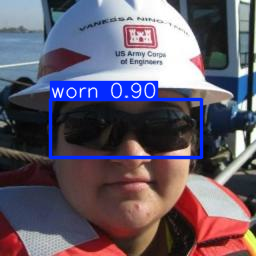

Number of objects found: 1


In [14]:
import random
val_img_dir = '/content/glasses_dataset/detection/worn/glasses-detection/val/images'
test_val_img = random.choice(os.listdir(val_img_dir))
results_val = model(os.path.join(val_img_dir, test_val_img))
res_val = results_val[0]
cv2_imshow(res_val.plot())
print(f"Number of objects found: {len(res_val.boxes)}")


image 1/1 /content/glasses_dataset/detection/eyes/glasses-detection/val/images/640px-man_pulling_face_at_camera_-288455760157-29_jpg.rf.da9b96c98469db11028faacefa77fd02.jpg: 640x640 1 worn, 16.9ms
Speed: 7.6ms preprocess, 16.9ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


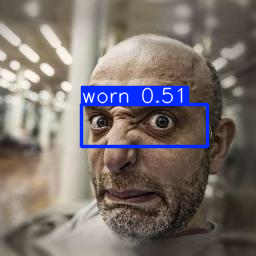

Number of objects found: 1


In [15]:
import random
val_img_dir = '/content/glasses_dataset/detection/eyes/glasses-detection/val/images'
test_val_img = random.choice(os.listdir(val_img_dir))
results_val = model(os.path.join(val_img_dir, test_val_img))
res_val = results_val[0]
cv2_imshow(res_val.plot())
print(f"Number of objects found: {len(res_val.boxes)}")

In [16]:
results_val

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'worn', 1: 'eyes', 2: 'solo'}
 obb: None
 orig_img: array([[[ 73,  82,  91],
         [ 74,  83,  92],
         [ 75,  84,  93],
         ...,
         [ 65,  76,  84],
         [ 63,  74,  82],
         [ 62,  73,  81]],
 
        [[ 73,  82,  91],
         [ 74,  83,  92],
         [ 75,  84,  93],
         ...,
         [ 64,  75,  83],
         [ 62,  73,  81],
         [ 61,  72,  80]],
 
        [[ 73,  82,  91],
         [ 73,  82,  91],
         [ 74,  83,  92],
         ...,
         [ 64,  73,  82],
         [ 61,  70,  79],
         [ 60,  69,  78]],
 
        ...,
 
        [[111, 127, 134],
         [110, 126, 133],
         [108, 124, 131],
         ...,
         [ 54,  59,  68],
         [ 53,  58,  67],
         [ 53,  58,  67]],
 
        [[112, 128, 135],
         [111, 127, 134],
         [109, 125, 132],
         ...

Этот ноутбук покрывает основные сценарии работы с YOLOv8 в Google Colab. Вы можете дорабатывать количество эпох, настраивать параметры тренировки и использовать собственные данные.